<a href="https://colab.research.google.com/github/SaiSiddharthD/Deepfake-Detection-Optimization/blob/main/Spectrograms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import librosa, librosa.display
import numpy as np
import tqdm.notebook as tq
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### File Setting

In [3]:
!unzip -o -q /content/drive/MyDrive/LibriSeVoc_Lite.zip
os.chdir("LibriSeVoc Lite/Real")
files = sorted(os.listdir())
SpecsReal = []
MfccReal = []

for file in tq.tqdm(files):
    if file.endswith(".wav"):
        signal, sr = librosa.load(file)
        spec = librosa.amplitude_to_db(np.abs(librosa.stft(signal)))
        SpecsReal.append(spec)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20)
        MfccReal.append(mfcc)
os.chdir("../Fake/diffwave")
files = sorted(os.listdir())
SpecsDiffwave = []
MfccDiffwave = []

for file in tq.tqdm(files):
    if file.endswith(".wav"):
        signal, sr = librosa.load(file)
        spec = librosa.amplitude_to_db(np.abs(librosa.stft(signal)))
        SpecsDiffwave.append(spec)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20)
        MfccDiffwave.append(mfcc)
os.chdir("../melgan")
files = sorted(os.listdir())
SpecsMelgan = []
MfccMelgan = []

for file in tq.tqdm(files):
    if file.endswith(".wav"):
        signal, sr = librosa.load(file)
        spec = librosa.amplitude_to_db(np.abs(librosa.stft(signal)))
        SpecsMelgan.append(spec)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20)
        MfccMelgan.append(mfcc)
os.chdir("../parallel_wave_gan")
files = sorted(os.listdir())
SpecsParallelWaveGan = []
MfccParallelWaveGan = []

for file in tq.tqdm(files):
    if file.endswith(".wav"):
        signal, sr = librosa.load(file)
        spec = librosa.amplitude_to_db(np.abs(librosa.stft(signal)))
        SpecsParallelWaveGan.append(spec)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20)
        MfccParallelWaveGan.append(mfcc)
os.chdir("../wavegrad")
files = sorted(os.listdir())
SpecsWavegrad = []
MfccWavegrad = []

for file in tq.tqdm(files):
    if file.endswith(".wav"):
        signal, sr = librosa.load(file)
        spec = librosa.amplitude_to_db(np.abs(librosa.stft(signal)))
        SpecsWavegrad.append(spec)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20)
        MfccWavegrad.append(mfcc)
os.chdir("../wavernn")
files = sorted(os.listdir())
SpecsWavernn = []
MfccWavernn = []

for file in tq.tqdm(files):
    if file.endswith(".wav"):
        signal, sr = librosa.load(file)
        spec = librosa.amplitude_to_db(np.abs(librosa.stft(signal)))
        SpecsWavernn.append(spec)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20)
        MfccWavernn.append(mfcc)
os.chdir("../wavenet")
files = sorted(os.listdir())
SpecsWavenet = []
MfccWavenet = []

for file in tq.tqdm(files):
    if file.endswith(".wav"):
        signal, sr = librosa.load(file)
        spec = librosa.amplitude_to_db(np.abs(librosa.stft(signal)))
        SpecsWavenet.append(spec)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20)
        MfccWavenet.append(mfcc)



  0%|          | 0/252 [00:00<?, ?it/s]

  0%|          | 0/252 [00:00<?, ?it/s]

  0%|          | 0/252 [00:00<?, ?it/s]

  0%|          | 0/252 [00:00<?, ?it/s]

  0%|          | 0/252 [00:00<?, ?it/s]

  0%|          | 0/252 [00:00<?, ?it/s]

  0%|          | 0/253 [00:00<?, ?it/s]

### Splitting The Data

In [4]:
all_spec_lists = [SpecsReal, SpecsDiffwave, SpecsMelgan, SpecsParallelWaveGan, SpecsWavegrad, SpecsWavernn, SpecsWavenet]
shortest = min([x.shape[1] for lst in all_spec_lists for x in lst])

In [5]:
import matplotlib.pyplot as plt
import os
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPool2D, GlobalAveragePooling2D
from sklearn.model_selection import train_test_split
import gdown
from ipywidgets import interact, IntSlider
import pandas as pd
import datetime
%load_ext tensorboard
!rm -rf ./logs/
from tensorflow.keras.utils import to_categorical
np.random.seed(12)
tf.random.set_seed(12)
DF_PATH = ('https://dpl6hyzg28thp.cloudfront.net/media/metadata.csv')
IMG_PATH = ('/content/drive/MyDrive/Spectrogram_Images')
NUM_IMS = 500
CHECKPOINT_PATH = 'checkpoint'
INPUT_SHAPE = (1025, shortest,1)
!rm -rf logs
!mkdir logs
!mkdir logs/fit/

def load_image_from_name(name):
    path = Path(IMG_PATH) / f'{name}.jpg'
    return plt.imread(path) / 255

def plot_dist(df):
    num2labs = {
        0:"diffwave"
        , 1:"real"
    }
    counts = df["level"].map(num2labs).value_counts() / len(df)
    counts.plot.bar()
    plt.title("Percentage of images in each class")
    plt.show()

def plot_helper(df, index):
    row = df.iloc[index]
    img = load_image_from_name(row.image)
    plt.title(f"Level: {row.level}")
    plt.imshow(img)

def normalize(img):
    return (img - img.min()) / (img.max() - img.min())

def MobileNet(freeze=False):
    model = tf.keras.applications.MobileNet(input_shape=INPUT_SHAPE, weights='imagenet', include_top=False)
    model.trainable= not freeze
    return tf.keras.Sequential([
        model,
        GlobalAveragePooling2D(),
        Dense(1, activation='sigmoid')
    ])

In [6]:
import gc
import numpy as np
from tensorflow.keras.utils import to_categorical

IDX = list(range(252))
x_train, x_val = train_test_split(IDX, shuffle=True, test_size=0.2)

n_train = len(x_train) * 7
n_val = len(x_val) * 7

SpecsTrain = np.empty((n_train, 1025, shortest, 1), dtype=np.float32)
SpecsTest = np.empty((n_val, 1025, shortest, 1), dtype=np.float32)
MfccTrain = np.empty((n_train, 20, shortest, 1), dtype=np.float32)
MfccTest = np.empty((n_val, 20, shortest, 1), dtype=np.float32)

y_train_raw = np.empty((n_train,), dtype=np.int8)
y_val_raw = np.empty((n_val,), dtype=np.int8)

all_specs = [SpecsDiffwave, SpecsMelgan, SpecsParallelWaveGan, SpecsReal, SpecsWavegrad, SpecsWavenet, SpecsWavernn]
all_mfccs = [MfccDiffwave, MfccMelgan, MfccParallelWaveGan, MfccReal, MfccWavegrad, MfccWavenet, MfccWavernn]

train_idx = 0
val_idx = 0
class_code = 0

for spec_vocoder, mfcc_vocoder in zip(all_specs, all_mfccs):
    for i in x_train:
        SpecsTrain[train_idx, :, :, 0] = spec_vocoder[i][:, :shortest]
        MfccTrain[train_idx, :, :, 0]  = mfcc_vocoder[i][:, :shortest]
        y_train_raw[train_idx] = class_code
        train_idx += 1

    for i in x_val:
        SpecsTest[val_idx, :, :, 0] = spec_vocoder[i][:, :shortest]
        MfccTest[val_idx, :, :, 0]  = mfcc_vocoder[i][:, :shortest]
        y_val_raw[val_idx] = class_code
        val_idx += 1

    class_code += 1

y_train = to_categorical(y_train_raw, 7)
y_val = to_categorical(y_val_raw, 7)

del all_specs, all_mfccs
del SpecsReal, SpecsDiffwave, SpecsMelgan, SpecsParallelWaveGan, SpecsWavegrad, SpecsWavenet, SpecsWavernn
del MfccReal, MfccDiffwave, MfccMelgan, MfccParallelWaveGan, MfccWavegrad, MfccWavenet, MfccWavernn
gc.collect()

87

###  Training Preparation


In [7]:
import os
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
os.environ['XLA_FLAGS'] = '--xla_gpu_autotune_level=0'

import math
import datetime
import tensorflow as tf
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch, lr):
    if epoch < 10:
        return 0.0001
    else:
        return float(lr * math.exp(-0.05))

def train(model, x_spec, x_mfcc, y, x_val_spec, x_val_mfcc, y_val, epochs):
    tf.keras.backend.clear_session()

    log_dir = "logs/" + model.name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
    lr_callback = LearningRateScheduler(lr_schedule)

    optimizer = tf.optimizers.Adam()
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

    return model.fit(
        x=[x_spec, x_mfcc],
        y=y,
        epochs=epochs,
        batch_size=8,
        validation_data=([x_val_spec, x_val_mfcc], y_val),
        callbacks=[tensorboard_callback, lr_callback],
        verbose=1,
    )

### Creating our Models



In [8]:
from tensorflow.keras.layers import Input, Concatenate, Dropout, BatchNormalization, Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.models import Model

input_spec = Input(shape=INPUT_SHAPE, name="spectrogram_input")
x = Conv2D(32, 3, activation="relu")(input_spec)
x = MaxPool2D()(x)
x = Conv2D(64, 3, activation="relu")(x)
x = MaxPool2D()(x)
x = Conv2D(64, 3, activation="relu")(x)
x = MaxPool2D(pool_size=(4, 4))(x)
x = Flatten()(x)
x = BatchNormalization()(x)

input_mfcc = Input(shape=(20, shortest, 1), name="mfcc_input")
y = Flatten()(input_mfcc)
y = BatchNormalization()(y)
y = Dense(64, activation="relu")(y)

fused = Concatenate()([x, y])
fused = BatchNormalization()(fused)
fused = Dense(32, activation="relu")(fused)
fused = Dropout(0.5)(fused)

outputs = Dense(7, activation='softmax')(fused)

conv_model = Model(inputs=[input_spec, input_mfcc], outputs=outputs, name="hybrid_late_fusion_v5")

### Model Training

In [9]:
hist = train(conv_model, SpecsTrain, MfccTrain, y_train, SpecsTest, MfccTest, y_val, epochs=32)

Epoch 1/32
176/176 ━━━━━━━━━━━━━━━━━━━━ 69s 340ms/step - accuracy: 0.3667 - loss: 1.9823 - val_accuracy: 0.4286 - val_loss: 2.2084 - learning_rate: 1.0000e-04
Epoch 2/32
176/176 ━━━━━━━━━━━━━━━━━━━━ 57s 322ms/step - accuracy: 0.5984 - loss: 1.0884 - val_accuracy: 0.6190 - val_loss: 1.1703 - learning_rate: 1.0000e-04
Epoch 3/32
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.7022 - loss: 0.8179 - val_accuracy: 0.5294 - val_loss: 1.7153 - learning_rate: 1.0000e-04
Epoch 4/32
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 319ms/step - accuracy: 0.7704 - loss: 0.6323 - val_accuracy: 0.2605 - val_loss: 5.6237 - learning_rate: 1.0000e-04
Epoch 5/32
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 319ms/step - accuracy: 0.7889 - loss: 0.5403 - val_accuracy: 0.4286 - val_loss: 3.5453 - learning_rate: 1.0000e-04
Epoch 6/32
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 320ms/step - accuracy: 0.8401 - loss: 0.4291 - val_accuracy: 0.4622 - val_loss: 5.5364 - learning_rate: 1.0000e-04
Epoch 7/32
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 32

### Plotting

In [10]:
import seaborn as sns
import matplotlib.pyplot as pyplot
from keras.callbacks import ReduceLROnPlateau
def plot_acc(history, ax = None, xlabel = 'Epoch #'):
    history = history.history
    history.update({'epoch':list(range(len(history['val_accuracy'])))})
    history = pd.DataFrame.from_dict(history)

    best_epoch = history.sort_values(by = 'val_accuracy', ascending = False).iloc[0]['epoch']

    if not ax:
      f, ax = plt.subplots(1,1)
    sns.lineplot(x = 'epoch', y = 'val_accuracy', data = history, label = 'Validation', ax = ax)
    sns.lineplot(x = 'epoch', y = 'accuracy', data = history, label = 'Training', ax = ax)
    ax.axhline(0.1, linestyle = '--',color='red', label = 'Chance')
    ax.axvline(x = best_epoch, linestyle = '--', color = 'green', label = 'Best Epoch')
    ax.legend(loc = 7)
    ax.set_ylim([min(min(history['val_accuracy']), min(history['accuracy'])), max(max(history['accuracy']), max(history['val_accuracy']))])

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy (Fraction)')

    plt.show()

learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

def plot_activations(model, input_image, im_per_row=16):
  layer_outputs = [layer.output for layer in model.layers[:8]]
  activation_model = models.Model(inputs=model.inputs, outputs=layer_outputs)
  activations = activation_model.predict(test_im.reshape(1,28,28,1))
  layer_names = []
  for layer in model.layers[:-1]:
      layer_names.append(layer.name)
  images_per_row = im_per_row
  for layer_name, layer_activation in zip(layer_names, activations):
      if layer_name.startswith('conv') or layer_name.startswith('max'):
          n_features = layer_activation.shape[-1]
          size = layer_activation.shape[1]
          n_cols = n_features // images_per_row
          display_grid = np.zeros((size * n_cols, images_per_row * size))
          for col in range(n_cols):
              for row in range(images_per_row):
                  channel_image = layer_activation[0,:, :, col * images_per_row + row]
                  channel_image -= channel_image.mean()
                  channel_image /= channel_image.std()
                  channel_image *= 64
                  channel_image += 128
                  channel_image = np.clip(channel_image, 0, 255).astype('uint8')
                  display_grid[col * size : (col + 1) * size,
                              row * size : (row + 1) * size] = channel_image
          scale = 1. / size
          plt.figure(figsize=(scale * display_grid.shape[1],
                              scale * display_grid.shape[0]))
          plt.title(layer_name)
          plt.grid(False)
          plt.imshow(display_grid, aspect='auto', cmap='viridis')

def plot_kernels(model, img_per_row=16):
  filters, biases = model.layers[0].get_weights()
  # normalize filter values to 0-1 so we can visualize them
  f_min, f_max = filters.min(), filters.max()
  filters = (filters - f_min) / (f_max - f_min)
  n_filters = filters.shape[-1]
  fig, ax = pyplot.subplots(n_filters//img_per_row, img_per_row, figsize=(15,2))
  for i in range(n_filters):
    f = filters[:, :, :, i]
    ax[i//img_per_row, i%img_per_row].set_xticks([])
    ax[i//img_per_row, i%img_per_row].set_yticks([])
    ax[i//img_per_row, i%img_per_row].imshow(f.reshape((5,5)), cmap='gray')
  pyplot.show()

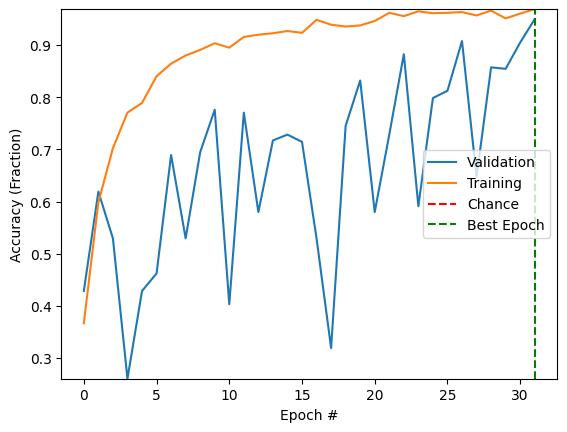

In [11]:
plot_acc(hist)

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [13]:
y_true=np.argmax(y_val, axis=1)
y_pred = np.argmax(conv_model.predict(SpecsTest), axis=1)

ValueError: Layer "hybrid_late_fusion_v5" expects 2 input(s), but it received 1 input tensors. Inputs received: [<tf.Tensor 'data:0' shape=(32, 1025, 172, 1) dtype=float32>]

In [ ]:
class_names=['F1', 'F2', 'F3', 'R', 'F4', 'F5', 'F6']

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Reds');

In [ ]:
RealPrecision=34/(3+1+34+2+1)

##TensorBoard

As we tune our hyperparameters, we'll have a **lot** of data to keep track of. Fortunately, there's a nifty tool to help us explore our model and results: TensorBoard. Run the line below to start it up:

In [ ]:
%tensorboard --logdir logs